# Векторизация текстов и сравнение их близости

Четыре текста на русском языке (сгенерированы LLM):
- `text1_machine_learning.txt` — Машинное обучение
- `text2_neural_networks.txt` — Нейронные сети и глубокое обучение
- `text3_russian_literature.txt` — Золотой век русской литературы
- `text4_russian_cuisine.txt` — Русская кухня

Метод векторизации: **TF-IDF** (Term Frequency – Inverse Document Frequency).  
Мера близости: **косинусное сходство** (cosine similarity).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
files = [
    ('text1_machine_learning.txt',  'ML'),
    ('text2_neural_networks.txt',   'Нейросети'),
    ('text3_russian_literature.txt','Литература'),
    ('text4_russian_cuisine.txt',   'Кухня'),
]

texts, labels = [], []
for fname, label in files:
    with open(fname, encoding='utf-8') as f:
        texts.append(f.read())
    labels.append(label)

for label, text in zip(labels, texts):
    print(f'{label}: {len(text)} символов')

ML: 4362 символов
Нейросети: 4722 символов
Литература: 4212 символов
Кухня: 4277 символов


## TF-IDF векторизация

TF-IDF взвешивает каждое слово по двум факторам:
- **TF** — как часто слово встречается в данном документе
- **IDF** — насколько редко слово встречается во всей коллекции (редкие слова несут больше информации)

В итоге каждый текст представляется вектором в пространстве всех уникальных слов коллекции.

In [3]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    token_pattern=r'[а-яёА-ЯЁa-zA-Z]{2,}',  # только слова длиной ≥2, без цифр и пунктуации
    min_df=1,
    sublinear_tf=True  # log(1 + tf) вместо tf — сглаживает влияние очень частых слов
)

tfidf_matrix = vectorizer.fit_transform(texts)
print(f'Размер матрицы TF-IDF: {tfidf_matrix.shape}')  # (4 текста, N уникальных слов)

Размер матрицы TF-IDF: (4, 1478)


## Матрица косинусного сходства

In [4]:
sim_matrix = cosine_similarity(tfidf_matrix)

print('Матрица косинусного сходства:')
header = f'{"":12}' + ''.join(f'{l:12}' for l in labels)
print(header)
for i, row_label in enumerate(labels):
    row = f'{row_label:12}' + ''.join(f'{sim_matrix[i, j]:.4f}      ' for j in range(len(labels)))
    print(row)

Матрица косинусного сходства:
            ML          Нейросети   Литература  Кухня       
ML          1.0000      0.1098      0.0356      0.0300      
Нейросети   0.1098      1.0000      0.0482      0.0254      
Литература  0.0356      0.0482      1.0000      0.0582      
Кухня       0.0300      0.0254      0.0582      1.0000      


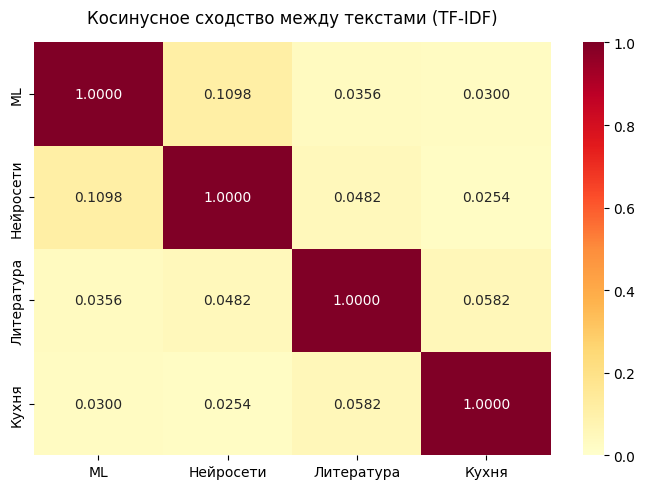

Тепловая карта сохранена в similarity_heatmap.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    sim_matrix,
    annot=True,
    fmt='.4f',
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    ax=ax
)
ax.set_title('Косинусное сходство между текстами (TF-IDF)', pad=14)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150)
plt.show()
print('Тепловая карта сохранена в similarity_heatmap.png')

In [6]:
n = len(labels)
pairs = [
    (labels[i], labels[j], sim_matrix[i, j])
    for i in range(n)
    for j in range(i + 1, n)
]
pairs.sort(key=lambda x: x[2], reverse=True)

print('Пары текстов по убыванию косинусного сходства:')
for a, b, score in pairs:
    print(f'  {a} — {b}: {score:.4f}')

Пары текстов по убыванию косинусного сходства:
  ML — Нейросети: 0.1098
  Литература — Кухня: 0.0582
  Нейросети — Литература: 0.0482
  ML — Литература: 0.0356
  ML — Кухня: 0.0300
  Нейросети — Кухня: 0.0254


## Анализ результатов

Результат в целом оказался таким, каким я его и ожидал — но было интересно посмотреть на конкретные числа.

Ближе всего друг к другу оказались тексты про **машинное обучение** и **нейронные сети** (cosine ≈ 0.11). Это логично: оба написаны в одной предметной области, и в обоих регулярно встречаются одни и те же специфические слова — *обучение*, *алгоритм*, *модель*, *данные*, *сеть*, *параметр*, *функция*. TF-IDF именно на это и реагирует: не на смысл, а на пересекающийся словарный запас.

Интересно, что **литература** и **кухня** тоже немного похожи друг на друга (≈ 0.058) — заметно больше, чем каждая из них похожа на тексты про ИИ. Скорее всего, это из-за общего слоя «гуманитарной» и «русско-культурной» лексики: слова *русский*, *традиция*, *период*, *особый*, *история* встречаются и там, и там. При этом доминирующая лексика у них, конечно, совершенно разная — Пушкин и борщ в одном векторном пространстве находятся далеко, — но этого общего фона хватает, чтобы слегка сблизить векторы.

Самые далёкие пары — **ML с кухней** и **нейросети с кухней** (≈ 0.025–0.03). Это тоже предсказуемо: у технических текстов и кулинарного практически нет общих содержательных слов.

Если бы вместо TF-IDF использовались семантические эмбеддинги (например, sentence-BERT или multilingual-E5), картина могла бы немного измениться: модели «понимают», что *нейрон* и *синапс* тематически близки к *алгоритму*, даже если эти слова не встречаются в одном тексте. Но для простой задачи на несколько текстов TF-IDF отработал честно и наглядно.